In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

import joblib

In [2]:
df = pd.read_csv("personal_expense_dataset.csv")

df.head()

,Date,Category,Amount,Payment_Mode,Month
0,1/1/2024,Transport,3279,Cash,May
1,1/2/2024,Entertainment,2080,Card,December
2,1/2/2024,Transport,3217,Online,December
3,1/2/2024,Utilities,1054,Online,May
4,1/5/2024,Food,13249,Cash,December


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          1000 non-null   object
 1   Category      1000 non-null   object
 2   Amount        1000 non-null   int64 
 3   Payment_Mode  1000 non-null   object
 4   Month         1000 non-null   object
dtypes: int64(1), object(4)
memory usage: 39.2+ KB


In [4]:
df.shape

(1000, 5)

In [5]:
df.describe()

,Amount
count,1000.000000
mean,7676.692000
std,4347.352771
min,101.000000
25%,3781.250000
50%,7938.000000
75%,11442.250000
max,14999.000000


In [6]:
df.isnull().sum()

Date            0
Category        0
Amount          0
Payment_Mode    0
Month           0
dtype: int64

In [7]:
#data cleaning
df.drop_duplicates(inplace=True)

df.dropna(inplace=True)

df.shape

(1000, 5)

In [8]:
#convert date
df['Date'] = pd.to_datetime(df['Date'])

df['Day'] = df['Date'].dt.day
df['Month_Number'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

df.head()

,Date,Category,Amount,Payment_Mode,Month,Day,Month_Number,Year
0,2024-01-01,Transport,3279,Cash,May,1,1,2024
1,2024-01-02,Entertainment,2080,Card,December,2,1,2024
2,2024-01-02,Transport,3217,Online,December,2,1,2024
3,2024-01-02,Utilities,1054,Online,May,2,1,2024
4,2024-01-05,Food,13249,Cash,December,5,1,2024


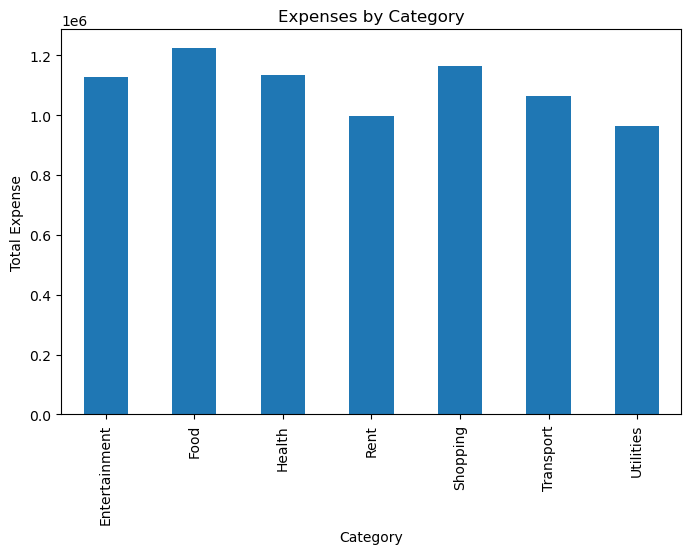

In [9]:
#Expense distribution by catagory
category_expense = df.groupby('Category')['Amount'].sum()

plt.figure(figsize=(8,5))

category_expense.plot(kind='bar')

plt.title("Expenses by Category")
plt.xlabel("Category")
plt.ylabel("Total Expense")

plt.show()

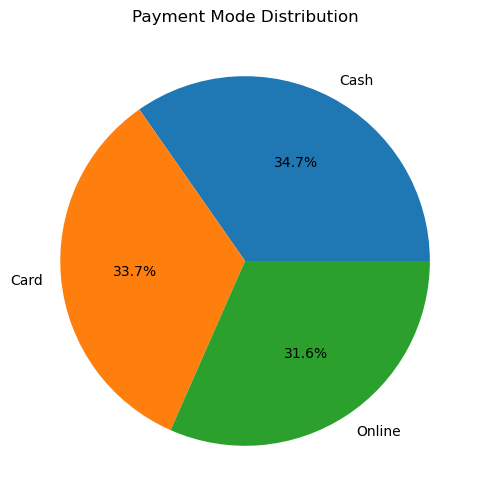

In [10]:
#payment mode analysis
payment = df['Payment_Mode'].value_counts()

plt.figure(figsize=(6,6))

payment.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Payment Mode Distribution")
plt.ylabel("")

plt.show()

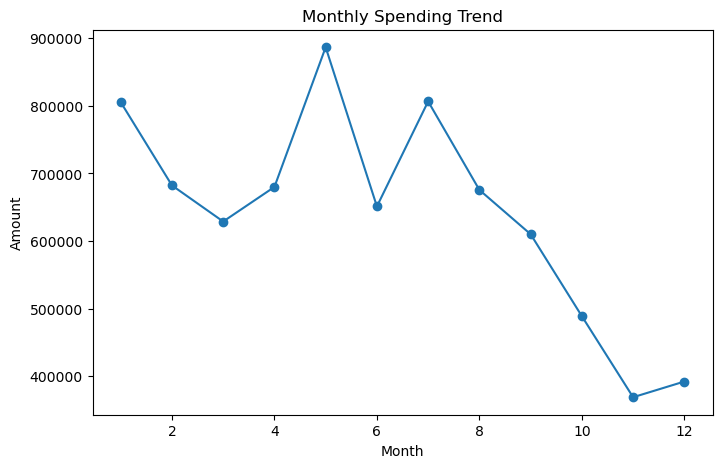

In [11]:
#monthly spending trend
monthly = df.groupby('Month_Number')['Amount'].sum()

plt.figure(figsize=(8,5))

monthly.plot(marker='o')

plt.title("Monthly Spending Trend")
plt.xlabel("Month")
plt.ylabel("Amount")

plt.show()

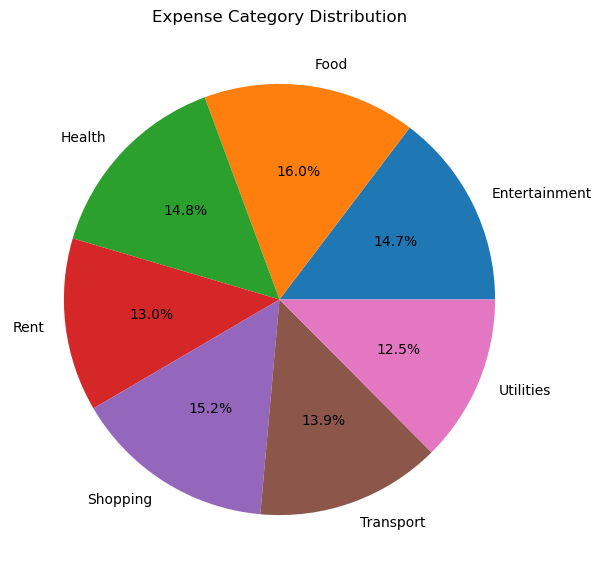

In [12]:
#category wise pie-chart
category_expense.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title("Expense Category Distribution")
plt.ylabel("")

plt.show()

In [13]:
#label encoding
le_category = LabelEncoder()
le_payment = LabelEncoder()
le_month = LabelEncoder()

df['Category'] = le_category.fit_transform(df['Category'])

df['Payment_Mode'] = le_payment.fit_transform(df['Payment_Mode'])

df['Month'] = le_month.fit_transform(df['Month'])

df.head()

,Date,Category,Amount,Payment_Mode,Month,Day,Month_Number,Year
0,2024-01-01,5,3279,1,8,1,1,2024
1,2024-01-02,0,2080,0,2,2,1,2024
2,2024-01-02,5,3217,2,2,2,1,2024
3,2024-01-02,6,1054,2,8,2,1,2024
4,2024-01-05,1,13249,1,2,5,1,2024


In [14]:
#feature engineering
df['Previous_Expense'] = df['Amount'].shift(1)

df.dropna(inplace=True)

df.head()

,Date,Category,Amount,Payment_Mode,Month,Day,Month_Number,Year,Previous_Expense
1,2024-01-02,0,2080,0,2,2,1,2024,3279.0
2,2024-01-02,5,3217,2,2,2,1,2024,2080.0
3,2024-01-02,6,1054,2,8,2,1,2024,3217.0
4,2024-01-05,1,13249,1,2,5,1,2024,1054.0
5,2024-01-05,0,14800,1,4,5,1,2024,13249.0


In [15]:
#create target variable
df['Future_Expense'] = df['Amount'].shift(-1)

df.dropna(inplace=True)

df.head()

,Date,Category,Amount,Payment_Mode,Month,Day,Month_Number,Year,Previous_Expense,Future_Expense
1,2024-01-02,0,2080,0,2,2,1,2024,3279.0,3217.0
2,2024-01-02,5,3217,2,2,2,1,2024,2080.0,1054.0
3,2024-01-02,6,1054,2,8,2,1,2024,3217.0,13249.0
4,2024-01-05,1,13249,1,2,5,1,2024,1054.0,14800.0
5,2024-01-05,0,14800,1,4,5,1,2024,13249.0,10856.0


In [16]:
#features and target
X = df[
    [
        'Category',
        'Payment_Mode',
        'Month',
        'Day',
        'Month_Number',
        'Previous_Expense'
    ]
]

y = df['Future_Expense']

In [17]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
#Linear Regression Model
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression Results")

print("MAE:",
      mean_absolute_error(y_test, lr_pred))

print("R2 Score:",
      r2_score(y_test, lr_pred))

Linear Regression Results
MAE: 3784.2347100928205
R2 Score: -0.004465573457114624


In [19]:
#Random Forest Model
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Results")

print("MAE:",
      mean_absolute_error(y_test, rf_pred))

print("R2 Score:",
      r2_score(y_test, rf_pred))

Random Forest Results
MAE: 3849.9111
R2 Score: -0.08671128404152584


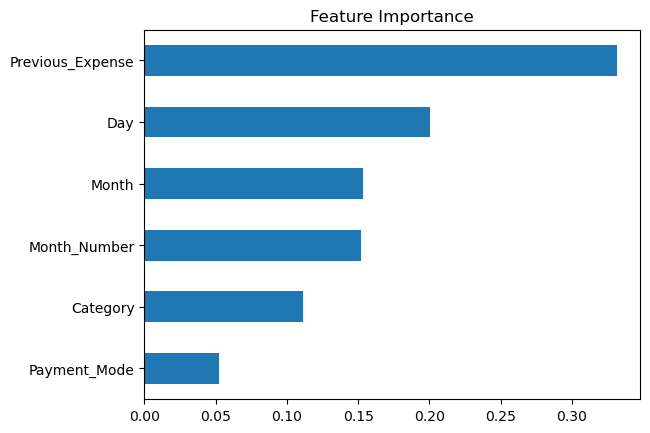

In [20]:
#feature importance
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh'
)

plt.title("Feature Importance")

plt.show()

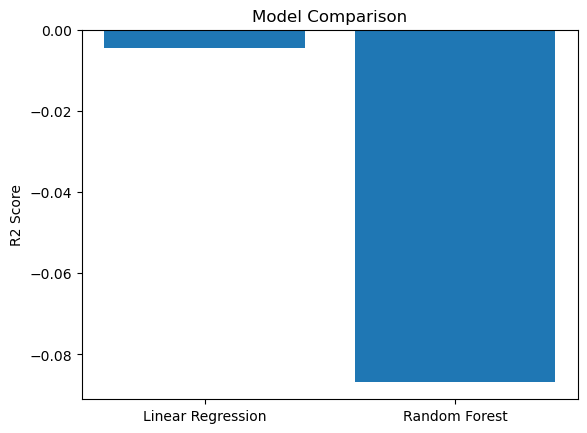

In [21]:
#Compare models
models = ['Linear Regression',
          'Random Forest']

scores = [
    r2_score(y_test, lr_pred),
    r2_score(y_test, rf_pred)
]

plt.bar(models, scores)

plt.ylabel("R2 Score")

plt.title("Model Comparison")

plt.show()

In [22]:
#save best model
joblib.dump(
    rf,
    "expense_prediction_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [23]:
#make predictions
predictions = pd.DataFrame({
    'Actual': y_test,
    'Predicted': rf_pred
})

predictions.head()

,Actual,Predicted
454,994.0,8813.15
793,10461.0,8487.04
210,5452.0,8574.78
310,2944.0,7555.84
740,5004.0,8290.03


In [24]:
#recomendation engine
def recommendation(amount):

    if amount > 10000:
        return "High Spending"

    elif amount > 5000:
        return "Moderate Spending"

    else:
        return "Good Savings Habit"


predictions['Recommendation'] = predictions[
    'Predicted'
].apply(recommendation)

predictions.head()

,Actual,Predicted,Recommendation
454,994.0,8813.15,Moderate Spending
793,10461.0,8487.04,Moderate Spending
210,5452.0,8574.78,Moderate Spending
310,2944.0,7555.84,Moderate Spending
740,5004.0,8290.03,Moderate Spending


In [25]:
#predict new data
sample = [[
    2,
    1,
    4,
    15,
    4,
    8500
]]

prediction = rf.predict(sample)

print(
    "Predicted Next Expense: ₹",
    round(prediction[0],2)
)

Predicted Next Expense: ₹ 6220.81


C:\Users\adity\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [26]:
pip install sqlalchemy pymysql

Note: you may need to restart the kernel to use updated packages.


In [29]:
from sqlalchemy import create_engine

engine = create_engine(
    "mysql+pymysql://root:@localhost/expense_db"
)

print("Engine Created Successfully")

Engine Created Successfully
